In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
none_df = pd.read_csv("walker_expert_none.csv")
none_df.head(5)

,step,reward_mean,reward_se,model
0,0,24.143553,0.995235,null+bc
1,20000,944.603766,4.783624,null+bc
2,40000,881.062750,41.857867,null+bc
3,60000,922.230988,29.725173,null+bc
4,80000,933.471550,9.021177,null+bc


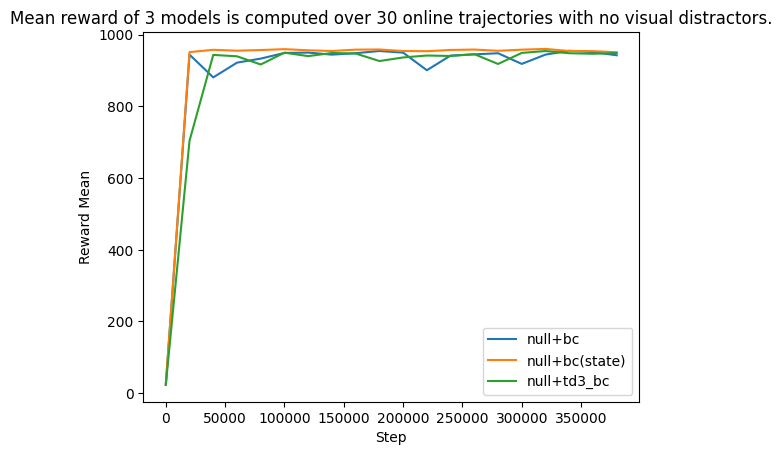

In [12]:
for model, group in none_df.groupby("model"):
    plt.plot(group["step"], group["reward_mean"], label=model)

plt.xlabel("Step")
plt.ylabel("Reward Mean")
plt.title("Mean reward of 3 models is computed over 30 online trajectories with no visual distractors.")
plt.legend()
plt.show()

In [16]:
dynamic_df = pd.read_csv("walker_expert_dynamic.csv")
dynamic_df.head(5)

,step,reward_mean,reward_se,model
0,0,21.967028,2.132386,null+td3_bc
1,20000,642.082854,30.609951,null+td3_bc
2,40000,641.915214,46.210216,null+td3_bc
3,60000,795.691378,30.623906,null+td3_bc
4,80000,688.990114,51.762628,null+td3_bc


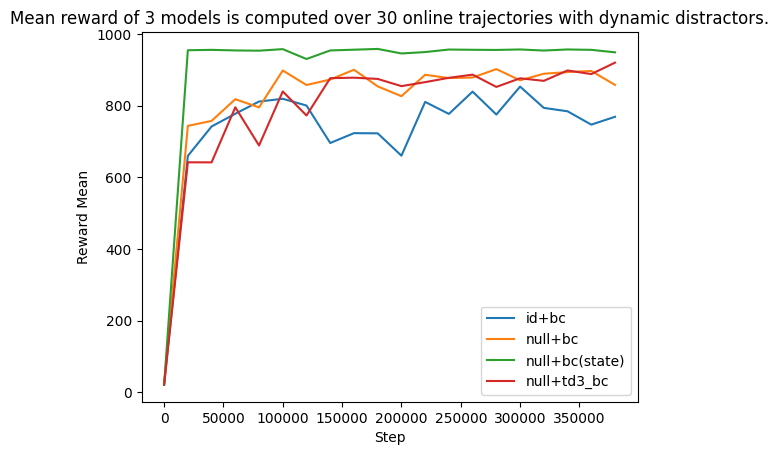

In [ ]:
for model, group in dynamic_df.groupby("model"):
    plt.plot(group["step"], group["reward_mean"], label=model)

plt.xlabel("Step")
plt.ylabel("Reward Mean")
plt.title("Mean reward of 4 models is computed over 30 online trajectories with dynamic distractors.")
plt.legend()
plt.show()

In [20]:
new_none_df = none_df.copy()
new_dynamic_df = dynamic_df.copy()
new_none_df["model"] = new_none_df["model"].apply(lambda x:  "none_" + x)
new_dynamic_df["model"] = new_dynamic_df["model"].apply(lambda x: "dynamic_" + x)
df_combined = pd.concat([new_none_df, new_dynamic_df], ignore_index=True)
df_combined.head(5)

,step,reward_mean,reward_se,model
0,0,24.143553,0.995235,none_null+bc
1,20000,944.603766,4.783624,none_null+bc
2,40000,881.062750,41.857867,none_null+bc
3,60000,922.230988,29.725173,none_null+bc
4,80000,933.471550,9.021177,none_null+bc


In [21]:
df_combined.loc[df_combined.groupby("model")["reward_mean"].idxmax()]

,step,reward_mean,reward_se,model
135,300000,853.340862,22.637854,dynamic_id+bc
114,280000,902.178147,15.326526,dynamic_null+bc
89,180000,958.465146,3.283345,dynamic_null+bc(state)
79,380000,920.205707,6.135249,dynamic_null+td3_bc
17,340000,955.376998,3.482272,none_null+bc
56,320000,960.509948,2.904725,none_null+bc(state)
36,320000,954.617962,2.685005,none_null+td3_bc
